### 1. Importing necessary packages

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, roc_curve

import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

### 2. Creating train and test sets

In [4]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e5/test.csv')

X_train = train.drop(['id', 'PitNextLap'], axis=1).copy()
y_train = train['PitNextLap'].copy()
X_test = test.drop('id', axis=1).copy()
test_ids = test['id'].values

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive class: {y_train.mean():.2%}")

Train: (439140, 14), Test: (188165, 14)
Positive class: 19.90%


### 3. Performing exploratory data analysis

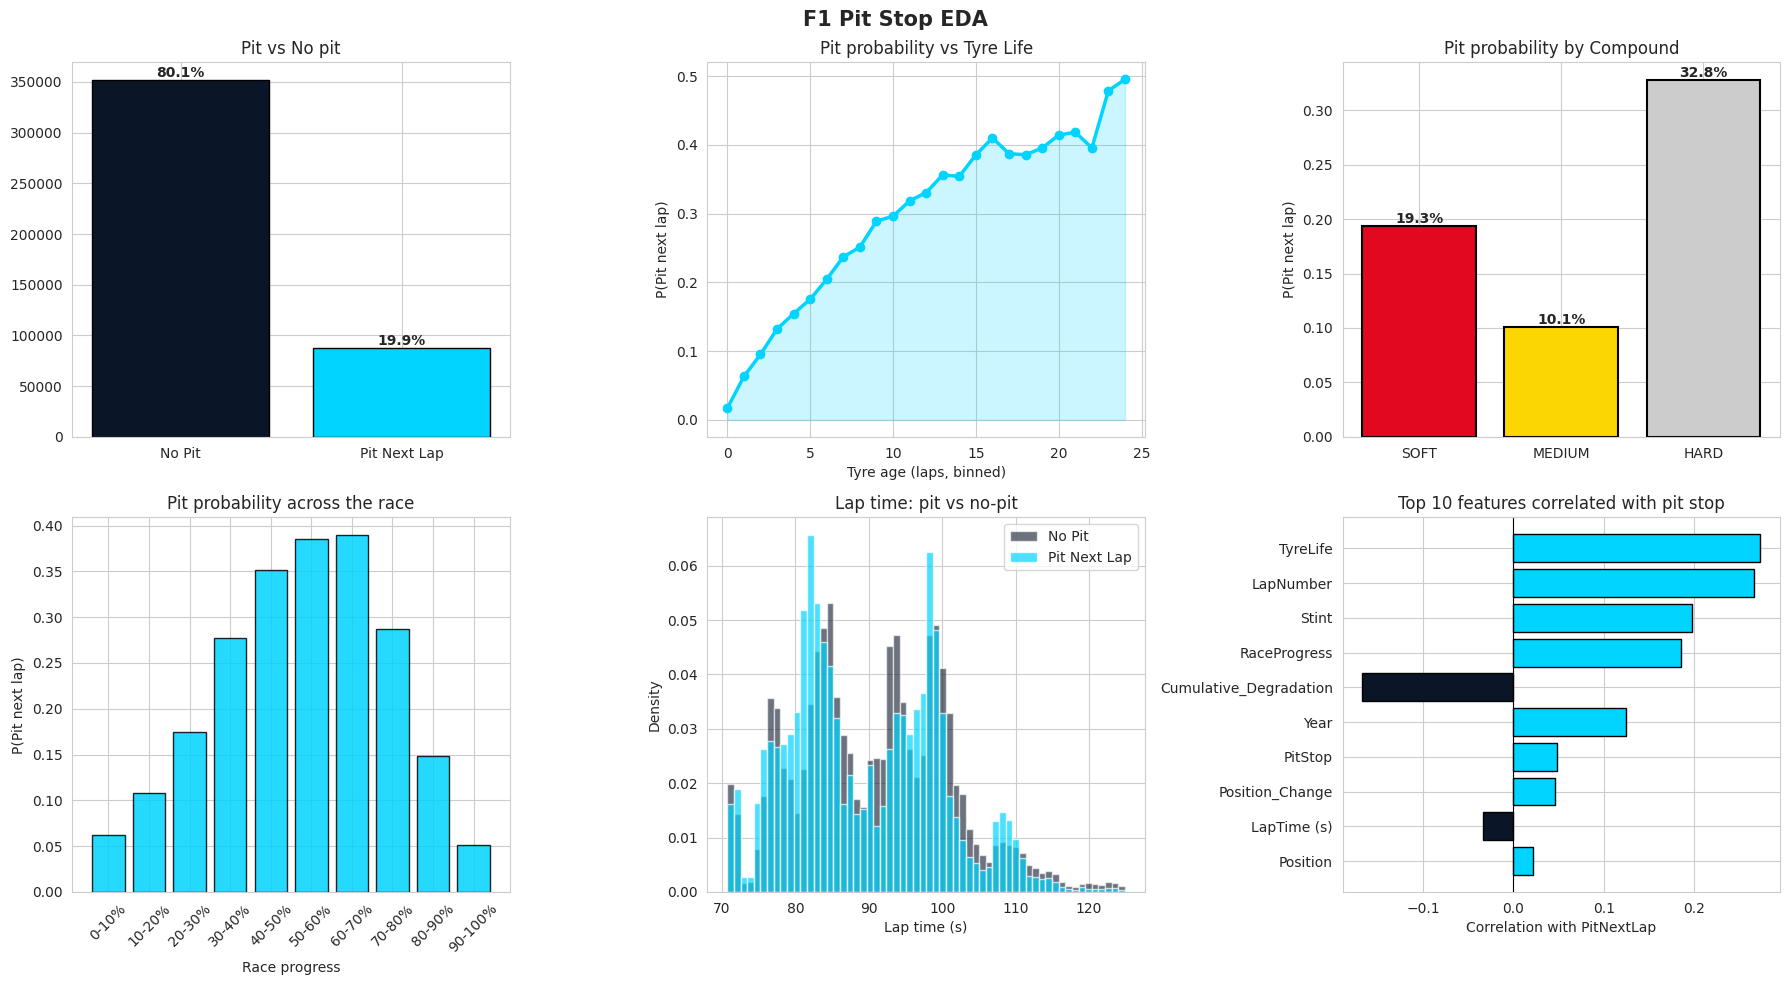

In [14]:
eda = train.copy()
F1_cyan = '#00D4FF'
F1_navy = '#0A1628'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('F1 Pit Stop EDA', fontsize=15, fontweight='bold')

# 1) Number of pits and no-pits
counts = eda['PitNextLap'].value_counts().sort_index()
axes[0, 0].bar(['No Pit', 'Pit Next Lap'], counts.values, color=[F1_navy, F1_cyan], edgecolor='black')
for i, v in enumerate(counts.values):
    axes[0, 0].text(i, v, f'{v/counts.sum():.1%}', ha='center', va='bottom', fontweight='bold')
axes[0, 0].set_title('Pit vs No pit')
axes[0, 0].set_ylabel('')

# 2) Pit rate vs Tyre Life
tyre_bins = pd.cut(eda['TyreLife'], bins=range(0, 51, 2))
pit_by_tyre = eda.groupby(tyre_bins)['PitNextLap'].mean()
axes[0, 1].plot(range(len(pit_by_tyre)), pit_by_tyre.values, color=F1_cyan, linewidth=2.5, marker='o')
axes[0, 1].fill_between(range(len(pit_by_tyre)), pit_by_tyre.values, alpha=0.2, color=F1_cyan)
axes[0, 1].set_title('Pit probability vs Tyre Life')
axes[0, 1].set_xlabel('Tyre age (laps, binned)')
axes[0, 1].set_ylabel('P(Pit next lap)')

# 3) Pit rate by Compound
compound_order = ['SOFT', 'MEDIUM', 'HARD']
comp_data = eda[eda['Compound'].isin(compound_order)].groupby('Compound')['PitNextLap'].mean().reindex(compound_order)
colors_comp = ['#E10820', '#FCD600', '#CCCCCC']
bars = axes[0, 2].bar(comp_data.index, comp_data.values, color=colors_comp, edgecolor='black', linewidth=1.5)
for bar, v in zip(bars, comp_data.values):
    axes[0, 2].text(bar.get_x() + bar.get_width()/2, v, f'{v:.1%}', ha='center', va='bottom', fontweight='bold')
axes[0, 2].set_title('Pit probability by Compound')
axes[0, 2].set_ylabel('P(Pit next lap)')

# 4) Pit rate by Race Progress
rp_bins = pd.cut(eda['RaceProgress'], bins=np.linspace(0, 1, 11))
pit_by_rp = eda.groupby(rp_bins)['PitNextLap'].mean()
axes[1, 0].bar(range(len(pit_by_rp)), pit_by_rp.values, color=F1_cyan, alpha=0.85, edgecolor='black')
axes[1, 0].set_xticks(range(len(pit_by_rp)))
axes[1, 0].set_xticklabels([f'{i*10}-{(i+1)*10}%' for i in range(len(pit_by_rp))], rotation=45)
axes[1, 0].set_title('Pit probability across the race')
axes[1, 0].set_xlabel('Race progress')
axes[1, 0].set_ylabel('P(Pit next lap)')

# 5) LapTime distribution: pit vs no-pit
laptime_clip = eda[eda['LapTime (s)'].between(eda['LapTime (s)'].quantile(0.01), eda['LapTime (s)'].quantile(0.99))]
axes[1, 1].hist(laptime_clip[laptime_clip['PitNextLap']==0]['LapTime (s)'], bins=60, alpha=0.6, label='No Pit', color=F1_navy, density=True)
axes[1, 1].hist(laptime_clip[laptime_clip['PitNextLap']==1]['LapTime (s)'], bins=60, alpha=0.7, label='Pit Next Lap', color=F1_cyan, density=True)
axes[1, 1].set_title('Lap time: pit vs no-pit')
axes[1, 1].set_xlabel('Lap time (s)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()

# 6) Top correlations with target
numeric_cols = eda.select_dtypes(include=[np.number]).drop(columns=['id', 'PitNextLap']).columns
corr_with_target = eda[list(numeric_cols) + ['PitNextLap']].corr()['PitNextLap'].drop('PitNextLap').sort_values(key=abs, ascending=False).head(10)
colors_corr = [F1_cyan if v > 0 else F1_navy for v in corr_with_target.values]
axes[1, 2].barh(range(len(corr_with_target)), corr_with_target.values, color=colors_corr, edgecolor='black')
axes[1, 2].set_yticks(range(len(corr_with_target)))
axes[1, 2].set_yticklabels(corr_with_target.index)
axes[1, 2].set_title('Top 10 features correlated with pit stop')
axes[1, 2].set_xlabel('Correlation with PitNextLap')
axes[1, 2].invert_yaxis()
axes[1, 2].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

**Insights**
1. Pitting is rare (approx. 20%)
2. Tyre life is a strong indicator of pitting in the next lap
3. Pit stops cluster in the mid-race window
4. Hard tyres pit with greater likelihood than softs (which is counterintuitive in my opinion — you'd expect SOFT to wear out faster. This likely reflects stint length confounding: drivers on HARD tyres tend to run longer stints, so by the time they pit, tyre life is already high. SOFT's lower rate (19.3%) may be because SOFT stints are shorter and pits are less predictable per lap.)
5. Lap times are different between pit and no-pit laps (slower lap times indicate degraded tyres)
6. Correlation chart signals that `TyreLife`, `Stint` and `RaceProgress` contribute more significantly to the likelihood of pitting. 

### 4. Feature Engineering
Adding more features based on earlier insights.

- `TyreLife`: Older tires → higher degradation → more likely to pit
- `Stint`: Longer stints → more likely to pit
- `RaceProgress`: Tyre management varies by race stage (early, mid, late)
- `Cumulative_Degradation`: To illustrate that soft tyres pit more than hards
- `Position`: Drivers racing aggressively (position jumps) → more likely to pit
- `Compound`: Soft tires degrade faster

In this step, we create new features to describe tyre life, tyre degradation rates, lap time changes, stint-tyre life connection and position-tyre life connection.

In [16]:
def engineer_features(df):
    df = df.copy()

    df['TyreLife_Squared'] = df['TyreLife'] ** 2
    df['TyreLife_Log'] = np.log1p(df['TyreLife'])
    df['TyreLife_Bin'] = pd.cut(df['TyreLife'], bins=[0, 10, 20, 30, 50], labels=[0, 1, 2, 3]).astype(float)

    df['Stint_TyreLife_Interaction'] = df['Stint'] * df['TyreLife']
    df['RaceProgress_TyreLife'] = df['RaceProgress'] * df['TyreLife']
    df['LapNumber_TyreLife'] = df['LapNumber'] * df['TyreLife']

    df['Degradation_per_Lap'] = df['Cumulative_Degradation'] / (df['LapNumber'] + 1)
    df['LapTime_Degradation'] = df['LapTime (s)'] * np.abs(df['Cumulative_Degradation'])

    df['Position_Racing'] = np.abs(df['Position_Change'])
    df['Position_TyreLife'] = df['Position'] * df['TyreLife']

    max_laptime = df['LapTime (s)'].max()
    df['LapTime_Ratio'] = df['LapTime (s)'] / (max_laptime + 1e-8) if max_laptime > 0 else 0.5
    df['LapTime_Delta_Abs'] = np.abs(df['LapTime_Delta'])
    df['LapTime_Consistency'] = 1.0 / (1.0 + np.abs(df['LapTime_Delta']))

    df['Early_Race'] = (df['RaceProgress'] < 0.3).astype(float)
    df['Mid_Race'] = ((df['RaceProgress'] >= 0.3) & (df['RaceProgress'] < 0.7)).astype(float)
    df['Late_Race'] = (df['RaceProgress'] >= 0.7).astype(float)

    compound_degradation = {'SOFT': 3, 'MEDIUM': 2, 'HARD': 1}
    df['Compound_DegradationRate'] = df['Compound'].map(compound_degradation).astype(float)
    df['Compound_DegradationRate'].fillna(2, inplace=True)

    df['Pit_Urgency'] = df['TyreLife'] * df['Compound_DegradationRate'] * (1 + df['RaceProgress'])
    df['Stint_Age'] = df['Stint'] + df['TyreLife'] / 30
    df['LapTime_Delta_TyreLife'] = df['LapTime_Delta'] * df['TyreLife']

    df = df.replace([np.inf, -np.inf], np.nan)
    return df

X_train_eng = engineer_features(X_train)
X_test_eng = engineer_features(X_test)
print(f"Created {X_train_eng.shape[1] - X_train.shape[1]} new features")

Created 20 new features


### 5. Data preprocessing: Target Encoding 

Each categorical column in the training data is replaced with the average pit stop rate for that respective category. For drivers that appear in the test set but not the training set, we fill it with the global avergae pit rate instead of living as NaN. 

There's also median imputation, where any NaNs are replaced with the median of their corresponding columns in the training set. 

In [20]:
categorical_cols = ['Driver', 'Compound', 'Race']
X_train_processed = X_train_eng.copy()
X_test_processed = X_test_eng.copy()

for col in categorical_cols:
    target_mean = y_train.groupby(X_train_eng[col]).mean()
    X_train_processed[col + '_Encoded'] = X_train_eng[col].map(target_mean).fillna(y_train.mean())
    X_test_processed[col + '_Encoded'] = X_test_eng[col].map(target_mean).fillna(y_train.mean())

X_train_processed = X_train_processed.drop(categorical_cols, axis=1)
X_test_processed = X_test_processed.drop(categorical_cols, axis=1)

imputer = SimpleImputer(strategy='median')
X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=X_train_processed.columns
)
X_test_processed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=X_test_processed.columns
)

print(f"Encoding complete: {X_train_processed.shape}")

Encoding complete: (439140, 34)


### 6. Train and Validation Splits, 80-20

In [21]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_processed, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Scale weight: {scale_pos_weight:.2f}")

Train: (351312, 34), Val: (87828, 34), Scale weight: 4.03


### 7a. XGBoost 

In [25]:
xgb_params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 7,
    'learning_rate': 0.08,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_lambda': 0.5,
    'reg_alpha': 0.3,
    'scale_pos_weight': scale_pos_weight,
    'min_child_weight': 5,
    'seed': 42,
    'tree_method': 'hist'
}

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)

xgb_model = xgb.train(
    xgb_params, dtrain, num_boost_round=500,
    evals=[(dval, 'eval')],
    callbacks=[xgb.callback.EarlyStopping(rounds=50, save_best=True)],
    verbose_eval=50
)

y_pred_xgb_train = xgb_model.predict(xgb.DMatrix(X_train_processed))
y_pred_xgb_test = xgb_model.predict(xgb.DMatrix(X_test_processed))
xgb_auc = roc_auc_score(y_train, y_pred_xgb_train)

print(f"XGBoost ROC-AUC: {xgb_auc:.6f}")

[0]	eval-auc:0.91128
[50]	eval-auc:0.93761
[100]	eval-auc:0.94277
[150]	eval-auc:0.94481
[200]	eval-auc:0.94612
[250]	eval-auc:0.94680
[300]	eval-auc:0.94729
[350]	eval-auc:0.94774
[400]	eval-auc:0.94800
[450]	eval-auc:0.94813
[499]	eval-auc:0.94825
XGBoost ROC-AUC: 0.963249


### 7b. Light GBM

In [27]:
import lightgbm as lgb

lgb_params = {
    'objective': 'binary',               # equivalent to 'binary:logistic'
    'metric': 'auc',                     # equivalent to 'eval_metric': 'auc'
    'num_leaves': 127,                   # equivalent to max_depth=7 (2^7 - 1 = 127)
    'learning_rate': 0.08,               # same
    'bagging_fraction': 0.8,             # equivalent to subsample
    'bagging_freq': 1,                   # must be set for bagging_fraction to activate
    'feature_fraction': 0.8,             # equivalent to colsample_bytree
    'lambda_l2': 0.5,                    # equivalent to reg_lambda
    'lambda_l1': 0.3,                    # equivalent to reg_alpha
    'scale_pos_weight': scale_pos_weight,# same — handles class imbalance
    'min_child_samples': 20,             # equivalent to min_child_weight (LGB uses sample count)
    'seed': 42,                          # same
    'device': 'cpu',                     # equivalent to tree_method='hist' (LGB uses hist by default)
    'verbose': -1                        # suppress LightGBM's own logging
}

# LightGBM uses its own Dataset format, like XGBoost's DMatrix
ltrain = lgb.Dataset(X_tr, label=y_tr)
lval   = lgb.Dataset(X_val, label=y_val, reference=ltrain)  # reference= is important for validation

lgb_model = lgb.train(
    lgb_params,
    ltrain,
    num_boost_round=500,                 # same
    valid_sets=[lval],
    valid_names=['eval'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),  # equivalent to XGB EarlyStopping
        lgb.log_evaluation(period=50)    # equivalent to verbose_eval=50
    ]
)

# LightGBM predicts probabilities directly (no Dataset wrapper needed)
y_pred_lgb_train = lgb_model.predict(X_train_processed)
y_pred_lgb_test  = lgb_model.predict(X_test_processed)
lgb_auc = roc_auc_score(y_train, y_pred_lgb_train)

Training until validation scores don't improve for 50 rounds
[50]	eval's auc: 0.942834
[100]	eval's auc: 0.946667
[150]	eval's auc: 0.947439
[200]	eval's auc: 0.94784
[250]	eval's auc: 0.948059
[300]	eval's auc: 0.948166
[350]	eval's auc: 0.948168
Early stopping, best iteration is:
[320]	eval's auc: 0.94826


### 8b. ROC curves for XGBoost and for LightGBM

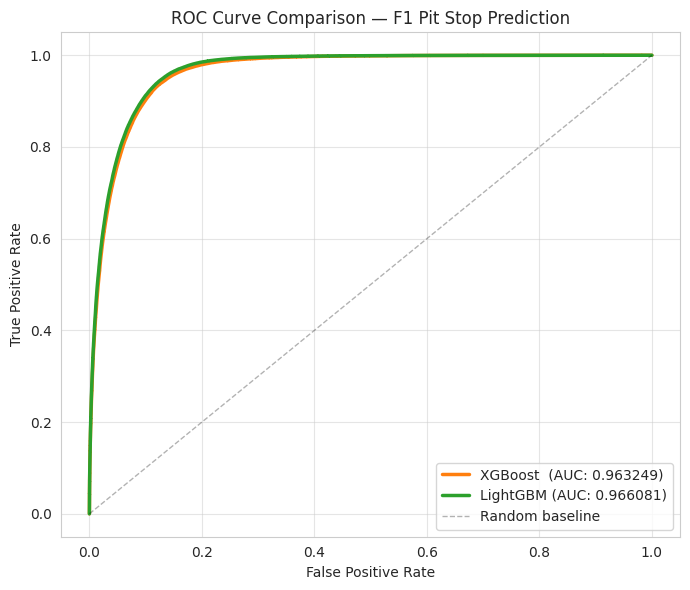

In [33]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_train, y_pred_xgb_train)
fpr_lgb, tpr_lgb, _ = roc_curve(y_train, y_pred_lgb_train)

plt.figure(figsize=(7, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost  (AUC: {xgb_auc:.6f})', linewidth=2.5, color='#ff7f0e')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC: {lgb_auc:.6f})', linewidth=2.5, color='#2ca02c')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.3, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — F1 Pit Stop Prediction')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

### 9. Generate Submission

In [38]:
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': y_pred_xgb_test
})

submission.to_csv('submission.csv', index=False)

print(f"Submission saved! Shape: {submission.shape}")
print(f"Mean probability: {submission['PitNextLap'].mean():.4f}")
print(submission.head())

Submission saved! Shape: (188165, 2)
Mean probability: 0.2891
       id  PitNextLap
0  439140    0.017394
1  439141    0.014386
2  439142    0.020029
3  439143    0.385030
4  439144    0.948340


In [37]:
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': y_pred_lgb_test
})

submission.to_csv('submission.csv', index=False)

print(f"Submission saved! Shape: {submission.shape}")
print(f"Mean probability: {submission['PitNextLap'].mean():.4f}")
print(submission.head())

Submission saved! Shape: (188165, 2)
Mean probability: 0.2862
       id  PitNextLap
0  439140    0.022050
1  439141    0.005353
2  439142    0.005030
3  439143    0.306163
4  439144    0.946530
